In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

import torch
from torch import nn, Tensor

# Dataset SetUp

In [65]:
data = np.load("DrellYan.npz")
data_H = np.load("Higgs.npz")

taus = data["x_taus"]        # shape (N, 2, 18)
tauprod = data["x_tauprod"]  # shape (N, 10, 10)
met = data["x_met"]          # shape (N, 1, 8)
jets = data["x_jets"]        # shape (N, 3, 4)

target = data["target"]      # (N, 2, 1) gen-level log(pt) of taus
m_reco = data["inv_mass_reco"]  # (N,)
m_target = data["inv_mass_tar"] # (N,)


taus_H   = data_H["x_taus"]          # (N, 2, 18)
tauprod_H = data_H["x_tauprod"]      # (N, 10, 10)
met_H    = data_H["x_met"]           # (N, 1, 8)
jets_H   = data_H["x_jets"]          # (N, 3, 4)

target_H = data_H["target"]          # (N, 2, 1)
m_reco_H  = data_H["inv_mass_reco"]   # (N,)
m_target_H = data_H["inv_mass_tar"]   # (N,)

In [66]:
df = pd.DataFrame({
    "tau1_logpt": taus[:,0,0],
    "tau1_eta":   taus[:,0,1],
    "tau1_phi":   taus[:,0,2],
    "tau1_mass":  taus[:,0,3],
    "tau1_dxy":   taus[:,0,4],
    "tau1_dz":    taus[:,0,5],
    "tau1_ptCorrPNet": taus[:,0,6],
    "tau1_rawPNetVSjet": taus[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus[:,0,8],
    "tau1_charge": taus[:,0,9],
    
    # decay mode indicator columns 
    "tau1_dM_0":  taus[:,0,10],
    "tau1_dM_1":  taus[:,0,11],
    "tau1_dM_2":  taus[:,0,12],
    "tau1_dM_10": taus[:,0,13],
    "tau1_dM_11": taus[:,0,14],
    
    "tau1_leadTkDeltaEta": taus[:,0,15],
    "tau1_leadTkDeltaPhi": taus[:,0,16],
    "tau1_leadTkPtOverTauPt": taus[:,0,17],

    "tau2_logpt": taus[:,1,0],
    "tau2_eta":   taus[:,1,1],
    "tau2_phi":   taus[:,1,2],
    "tau2_mass":  taus[:,1,3],
    "tau2_dxy":   taus[:,1,4],
    "tau2_dz":    taus[:,1,5],
    "tau2_ptCorrPNet": taus[:,1,6],
    "tau2_rawPNetVSjet": taus[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus[:,1,8],
    "tau2_charge": taus[:,1,9],

    "tau2_dM_0":  taus[:,1,10],
    "tau2_dM_1":  taus[:,1,11],
    "tau2_dM_2":  taus[:,1,12],
    "tau2_dM_10": taus[:,1,13],
    "tau2_dM_11": taus[:,1,14],

    "tau2_leadTkDeltaEta": taus[:,1,15],
    "tau2_leadTkDeltaPhi": taus[:,1,16],
    "tau2_leadTkPtOverTauPt": taus[:,1,17],

    "gen_tau1_logpt": target[:,0,0],
    "gen_tau2_logpt": target[:,1,0],

    "inv_mass_reco": m_reco,
    "inv_mass_tar":  m_target,
})


df_H = pd.DataFrame({
    "tau1_logpt": taus_H[:,0,0],
    "tau1_eta":   taus_H[:,0,1],
    "tau1_phi":   taus_H[:,0,2],
    "tau1_mass":  taus_H[:,0,3],
    "tau1_dxy":   taus_H[:,0,4],
    "tau1_dz":    taus_H[:,0,5],
    "tau1_ptCorrPNet": taus_H[:,0,6],
    "tau1_rawPNetVSjet": taus_H[:,0,7],
    "tau1_rawDeepTau2018v2p5VSjet": taus_H[:,0,8],
    "tau1_charge": taus_H[:,0,9],
    
    # decay mode indicator columns (same as DY)
    "tau1_dM_0":  taus_H[:,0,10],
    "tau1_dM_1":  taus_H[:,0,11],
    "tau1_dM_2":  taus_H[:,0,12],
    "tau1_dM_10": taus_H[:,0,13],
    "tau1_dM_11": taus_H[:,0,14],
    
    "tau1_leadTkDeltaEta": taus_H[:,0,15],
    "tau1_leadTkDeltaPhi": taus_H[:,0,16],
    "tau1_leadTkPtOverTauPt": taus_H[:,0,17],

    "tau2_logpt": taus_H[:,1,0],
    "tau2_eta":   taus_H[:,1,1],
    "tau2_phi":   taus_H[:,1,2],
    "tau2_mass":  taus_H[:,1,3],
    "tau2_dxy":   taus_H[:,1,4],
    "tau2_dz":    taus_H[:,1,5],
    "tau2_ptCorrPNet": taus_H[:,1,6],
    "tau2_rawPNetVSjet": taus_H[:,1,7],
    "tau2_rawDeepTau2018v2p5VSjet": taus_H[:,1,8],
    "tau2_charge": taus_H[:,1,9],

    "tau2_dM_0":  taus_H[:,1,10],
    "tau2_dM_1":  taus_H[:,1,11],
    "tau2_dM_2":  taus_H[:,1,12],
    "tau2_dM_10": taus_H[:,1,13],
    "tau2_dM_11": taus_H[:,1,14],

    "tau2_leadTkDeltaEta": taus_H[:,1,15],
    "tau2_leadTkDeltaPhi": taus_H[:,1,16],
    "tau2_leadTkPtOverTauPt": taus_H[:,1,17],

    "gen_tau1_logpt": target_H[:,0,0],
    "gen_tau2_logpt": target_H[:,1,0],

    "inv_mass_reco": m_reco_H,
    "inv_mass_tar":  m_target_H,
})


In [67]:
df["tau1_pt_reco"] = np.exp(df["tau1_logpt"])
df["tau2_pt_reco"] = np.exp(df["tau2_logpt"])

df["tau1_pt_gen"] = df["gen_tau1_logpt"]
df["tau2_pt_gen"] = df["gen_tau2_logpt"]


df_H["tau1_pt_reco"] = np.exp(df_H["tau1_logpt"])
df_H["tau2_pt_reco"] = np.exp(df_H["tau2_logpt"])

df_H["tau1_pt_gen"] = df_H["gen_tau1_logpt"]
df_H["tau2_pt_gen"] = df_H["gen_tau2_logpt"]

df["tau1_ptreco_over_ptgen"] = df["tau1_pt_reco"]/df["tau1_pt_gen"]
df["tau2_ptreco_over_ptgen"] = df["tau2_pt_reco"]/df["tau2_pt_gen"]

df_H["tau1_ptreco_over_ptgen"] = df_H["tau1_pt_reco"]/df_H["tau1_pt_gen"]
df_H["tau2_ptreco_over_ptgen"] = df_H["tau2_pt_reco"]/df_H["tau2_pt_gen"]

In [68]:
log_pt_min = np.log(30.0)   # ~3.401

mask_pt = (df["tau1_logpt"] > log_pt_min) & (df["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df))
print("Eventi che passano pT>30 GeV (in log):", mask_pt.sum())

df_sel = df[mask_pt].copy()

mask_pt_H = (df_H["tau1_logpt"] > log_pt_min) & (df_H["tau2_logpt"] > log_pt_min)

print("Eventi totali:", len(df_H))
print("Eventi che passano pT>30 GeV (in log):", mask_pt_H.sum())

df_H_sel = df_H[mask_pt_H].copy()

Eventi totali: 335263
Eventi che passano pT>30 GeV (in log): 69198
Eventi totali: 355225
Eventi che passano pT>30 GeV (in log): 158632


In [69]:
df_sel["tau1_abs_eta"] = df_sel["tau1_eta"].abs()
df_sel["tau2_abs_eta"] = df_sel["tau2_eta"].abs()

df_sel["tau1_is_barrel"] = df_sel["tau1_abs_eta"] < 1.4
df_sel["tau1_is_endcap"] = ~df_sel["tau1_is_barrel"]

df_sel["tau2_is_barrel"] = df_sel["tau2_abs_eta"] < 1.4
df_sel["tau2_is_endcap"] = ~df_sel["tau2_is_barrel"]


df_H_sel["tau1_abs_eta"] = df_H_sel["tau1_eta"].abs()
df_H_sel["tau2_abs_eta"] = df_H_sel["tau2_eta"].abs()

df_H_sel["tau1_is_barrel"] = df_H_sel["tau1_abs_eta"] < 1.4
df_H_sel["tau1_is_endcap"] = ~df_H_sel["tau1_is_barrel"]

df_H_sel["tau2_is_barrel"] = df_H_sel["tau2_abs_eta"] < 1.4
df_H_sel["tau2_is_endcap"] = ~df_H_sel["tau2_is_barrel"]

In [70]:
summary = pd.DataFrame({
    "Process": ["Drell–Yan", "Higgs"],
    "Total events": [len(df), len(df_H)],
    "After pT>30 GeV cut": [mask_pt.sum(), mask_pt_H.sum()]
})

summary["Retention (%)"] = 100 * summary["After pT>30 GeV cut"] / summary["Total events"]
summary


,Process,Total events,After pT>30 GeV cut,Retention (%)
0,Drell–Yan,335263,69198,20.639916
1,Higgs,355225,158632,44.656767


In [71]:
# Plot m_reco, m_tar e risoluzione :

# DY (dopo taglio pT)
m_reco_DY    = df_sel["inv_mass_reco"].values
m_target_DY  = df_sel["inv_mass_tar"].values

# Higgs (dopo taglio pT)
m_reco_H     = df_H_sel["inv_mass_reco"].values
m_target_H   = df_H_sel["inv_mass_tar"].values

# Risoluzioni relative
res_DY = (m_reco_DY - m_target_DY) / m_target_DY
res_H  = (m_reco_H  - m_target_H) / m_target_H

In [72]:
df_sel["tau1_response"] = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau1_resolution"] = (df_sel["tau1_pt_reco"] - df_sel["tau1_pt_gen"]) / df_sel["tau1_pt_gen"]

df_sel["tau2_response"] = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]
df_sel["tau2_resolution"] = (df_sel["tau2_pt_reco"] - df_sel["tau2_pt_gen"]) / df_sel["tau2_pt_gen"]


df_H_sel["tau1_response"] = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau1_resolution"] = (df_H_sel["tau1_pt_reco"] - df_H_sel["tau1_pt_gen"]) / df_H_sel["tau1_pt_gen"]

df_H_sel["tau2_response"] = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]
df_H_sel["tau2_resolution"] = (df_H_sel["tau2_pt_reco"] - df_H_sel["tau2_pt_gen"]) / df_H_sel["tau2_pt_gen"]

# pT corretta con PNet
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# response corretta
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]


# pT corretta con PNet
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# response corretta
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]


In [73]:
dm_map = {
    "dM_0": 0, "dM_1": 1, "dM_2": 2,
    "dM_10": 10, "dM_11": 11
}

dm_values = [0, 1, 2, 10, 11]

dm_labels = {
    0: "DM 0 (1-prong, 0 π0)",
    1: "DM 1 (1-prong, 1 π0)",
    2: "DM 2 (1-prong, 2 π0)",
    10: "DM 10 (3-prong, 0 π0)",
    11: "DM 11 (3-prong, 1 π0)",
}


# DY
df_sel["tau1_dm"] = (
      df_sel["tau1_dM_0"]  * 0
    + df_sel["tau1_dM_1"]  * 1
    + df_sel["tau1_dM_2"]  * 2
    + df_sel["tau1_dM_10"] * 10
    + df_sel["tau1_dM_11"] * 11
)

df_sel["tau2_dm"] = (
      df_sel["tau2_dM_0"]  * 0
    + df_sel["tau2_dM_1"]  * 1
    + df_sel["tau2_dM_2"]  * 2
    + df_sel["tau2_dM_10"] * 10
    + df_sel["tau2_dM_11"] * 11
)

# Higgs
df_H_sel["tau1_dm"] = (
      df_H_sel["tau1_dM_0"]  * 0
    + df_H_sel["tau1_dM_1"]  * 1
    + df_H_sel["tau1_dM_2"]  * 2
    + df_H_sel["tau1_dM_10"] * 10
    + df_H_sel["tau1_dM_11"] * 11
)

df_H_sel["tau2_dm"] = (
      df_H_sel["tau2_dM_0"]  * 0
    + df_H_sel["tau2_dM_1"]  * 1
    + df_H_sel["tau2_dM_2"]  * 2
    + df_H_sel["tau2_dM_10"] * 10
    + df_H_sel["tau2_dM_11"] * 11
)

In [74]:
# definizioni utili
# ----- DY -----
df_sel["tau1_response"]   = df_sel["tau1_pt_reco"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response"]   = df_sel["tau2_pt_reco"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution"] = df_sel["tau1_response"] - 1.0
df_sel["tau2_resolution"] = df_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_sel["tau1_pt_reco_corrPNet"] = df_sel["tau1_pt_reco"] * df_sel["tau1_ptCorrPNet"]
df_sel["tau2_pt_reco_corrPNet"] = df_sel["tau2_pt_reco"] * df_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_sel["tau1_response_corrPNet"] = df_sel["tau1_pt_reco_corrPNet"] / df_sel["tau1_pt_gen"]
df_sel["tau2_response_corrPNet"] = df_sel["tau2_pt_reco_corrPNet"] / df_sel["tau2_pt_gen"]

df_sel["tau1_resolution_corrPNet"] = df_sel["tau1_response_corrPNet"] - 1.0
df_sel["tau2_resolution_corrPNet"] = df_sel["tau2_response_corrPNet"] - 1.0


# ----- HIGGS -----
df_H_sel["tau1_response"]   = df_H_sel["tau1_pt_reco"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response"]   = df_H_sel["tau2_pt_reco"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution"] = df_H_sel["tau1_response"] - 1.0
df_H_sel["tau2_resolution"] = df_H_sel["tau2_response"] - 1.0

# PNet-corrected pT
df_H_sel["tau1_pt_reco_corrPNet"] = df_H_sel["tau1_pt_reco"] * df_H_sel["tau1_ptCorrPNet"]
df_H_sel["tau2_pt_reco_corrPNet"] = df_H_sel["tau2_pt_reco"] * df_H_sel["tau2_ptCorrPNet"]

# PNet-corrected response
df_H_sel["tau1_response_corrPNet"] = df_H_sel["tau1_pt_reco_corrPNet"] / df_H_sel["tau1_pt_gen"]
df_H_sel["tau2_response_corrPNet"] = df_H_sel["tau2_pt_reco_corrPNet"] / df_H_sel["tau2_pt_gen"]

df_H_sel["tau1_resolution_corrPNet"] = df_H_sel["tau1_response_corrPNet"] - 1.0
df_H_sel["tau2_resolution_corrPNet"] = df_H_sel["tau2_response_corrPNet"] - 1.0


# $\tau$ ID

In [75]:
# ================================
# TAU1 / TAU2 VALID — Drell–Yan
# ================================

df_sel_tau1_valid = df_sel[
    df_sel["tau1_rawPNetVSjet"] != -1
].copy()

df_sel_tau2_valid = df_sel[
    df_sel["tau2_rawPNetVSjet"] != -1
].copy()

print("DY valid taus:")
print("  tau1 valid =", len(df_sel_tau1_valid))
print("  tau2 valid =", len(df_sel_tau2_valid))

# ================================
# TAU1 / TAU2 VALID — Higgs
# ================================

df_H_sel_tau1_valid = df_H_sel[
    df_H_sel["tau1_rawPNetVSjet"] != -1
].copy()

df_H_sel_tau2_valid = df_H_sel[
    df_H_sel["tau2_rawPNetVSjet"] != -1
].copy()

print("\nHiggs valid taus:")
print("  tau1 valid =", len(df_H_sel_tau1_valid))
print("  tau2 valid =", len(df_H_sel_tau2_valid))

DY valid taus:
  tau1 valid = 69054
  tau2 valid = 68905

Higgs valid taus:
  tau1 valid = 158451
  tau2 valid = 158064


In [76]:
def find_threshold_for_efficiency(thresholds, efficiencies, target_eff=0.90):
    """
    Trova la soglia il cui valore di efficienza è più vicino a target_eff.
    """
    idx = np.argmin(np.abs(efficiencies - target_eff))
    return thresholds[idx], efficiencies[idx]

target_eff = 0.90

# ================================================
# TAU1 — HIGGS
# ================================================
vals_tau1 = df_H_sel_tau1_valid["tau1_rawPNetVSjet"].values

# Soglie reali possibili (ordinate e senza duplicati)
thresholds_tau1 = np.sort(np.unique(vals_tau1))

# Efficienza: P(rawPNet > thr)
eff_tau1 = np.array([np.mean(vals_tau1 > thr) for thr in thresholds_tau1])

thr_tau1, eff_at_thr_tau1 = find_threshold_for_efficiency(thresholds_tau1, eff_tau1, target_eff)

print(f"[Higgs] Tau1: soglia = {thr_tau1:.6f}, efficienza ≈ {eff_at_thr_tau1:.4f}")

# ================================================
# TAU2 — HIGGS
# ================================================
vals_tau2 = df_H_sel_tau2_valid["tau2_rawPNetVSjet"].values

thresholds_tau2 = np.sort(np.unique(vals_tau2))

eff_tau2 = np.array([np.mean(vals_tau2 > thr) for thr in thresholds_tau2])

thr_tau2, eff_at_thr_tau2 = find_threshold_for_efficiency(thresholds_tau2, eff_tau2, target_eff)

print(f"[Higgs] Tau2: soglia = {thr_tau2:.6f}, efficienza ≈ {eff_at_thr_tau2:.4f}")

[Higgs] Tau1: soglia = 0.642090, efficienza ≈ 0.9000
[Higgs] Tau2: soglia = 0.495850, efficienza ≈ 0.9000


In [77]:
# ============================
# HIGGS: applico le soglie
# ============================

# tau1 Higgs
mask_H_tau1_eff = df_H_sel_tau1_valid["tau1_rawPNetVSjet"] > thr_tau1
df_H_sel_tau1_eff = df_H_sel_tau1_valid[mask_H_tau1_eff].copy()

# tau2 Higgs
mask_H_tau2_eff = df_H_sel_tau2_valid["tau2_rawPNetVSjet"] > thr_tau2
df_H_sel_tau2_eff = df_H_sel_tau2_valid[mask_H_tau2_eff].copy()

# efficienze effettive (dovrebbero essere 0.90)
eff_H_tau1 = len(df_H_sel_tau1_eff) / len(df_H_sel_tau1_valid) if len(df_H_sel_tau1_valid) > 0 else float("nan")
eff_H_tau2 = len(df_H_sel_tau2_eff) / len(df_H_sel_tau2_valid) if len(df_H_sel_tau2_valid) > 0 else float("nan")

print("[Higgs] efficienze effettive:")
print(f"  tau1: {eff_H_tau1:.4f}")
print(f"  tau2: {eff_H_tau2:.4f}")


# ============================
# DY: applico le STESSE soglie
# ============================

# tau1 DY
mask_DY_tau1_eff = df_sel_tau1_valid["tau1_rawPNetVSjet"] > thr_tau1
df_sel_tau1_eff = df_sel_tau1_valid[mask_DY_tau1_eff].copy()

# tau2 DY
mask_DY_tau2_eff = df_sel_tau2_valid["tau2_rawPNetVSjet"] > thr_tau2
df_sel_tau2_eff = df_sel_tau2_valid[mask_DY_tau2_eff].copy()

# efficienze su DY (non devono per forza essere 0.90)
eff_DY_tau1 = len(df_sel_tau1_eff) / len(df_sel_tau1_valid) if len(df_sel_tau1_valid) > 0 else float("nan")
eff_DY_tau2 = len(df_sel_tau2_eff) / len(df_sel_tau2_valid) if len(df_sel_tau2_valid) > 0 else float("nan")

print("\n[DY] efficienze risultanti con soglie fissate da Higgs:")
print(f"  tau1: {eff_DY_tau1:.4f}")
print(f"  tau2: {eff_DY_tau2:.4f}")


[Higgs] efficienze effettive:
  tau1: 0.9000
  tau2: 0.9000

[DY] efficienze risultanti con soglie fissate da Higgs:
  tau1: 0.8525
  tau2: 0.8724


In [78]:
df_tauid_thresholds = pd.DataFrame({
    "Tau": ["Tau1", "Tau2"],
    "Threshold (rawPNet)": [thr_tau1, thr_tau2],
    "Efficiency (%)": [eff_at_thr_tau1 * 100, eff_at_thr_tau2 * 100]
})

df_tauid_thresholds = df_tauid_thresholds.set_index("Tau")
df_tauid_thresholds

,Threshold (rawPNet),Efficiency (%)
Tau,,
Tau1,0.64209,89.996908
Tau2,0.49585,90.002784


In [79]:
df_DY_tau1 = df_sel_tau1_eff.copy()
df_DY_tau2 = df_sel_tau2_eff.copy()

df_H_tau1 = df_H_sel_tau1_eff.copy()
df_H_tau2 = df_H_sel_tau2_eff.copy()

# Model

In [106]:
import time
import torch

from torch import nn, Tensor

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt

from matplotlib import cm


# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [107]:
# ===== TAU 1 =====

# x = target (gen pT del tau1)
x_cols = ["gen_tau1_logpt"]   # Dx = 1

# c = contesto (feature reco del tau1)
c_cols = [c for c in df_DY_tau1.columns if c.startswith("tau1_")]
c_cols += ["inv_mass_reco"]

X = df_DY_tau1[x_cols].to_numpy(np.float32)   # (N,1)
C = df_DY_tau1[c_cols].to_numpy(np.float32)   # (N,Dc)

print("X shape:", X.shape)
print("C shape:", C.shape)

X shape: (58870, 1)
C shape: (58870, 31)


### Normalizzazione:
- rende l’ottimizzazione stabile
- evita che il modello impazzisca per scale diverse $\rightarrow$ Do "lo stesso peso" a variabili di ordini diversi

In [101]:
# ============ OLD -> Normalizzazione fatta a mano ============
def standardize_fit(arr):
    mu = arr.mean(axis=0)
    std = arr.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return mu.astype(np.float32), std.astype(np.float32)

def standardize_apply(arr, mu, std):
    return ((arr - mu) / std).astype(np.float32)

# applico lo scaling : 
mu_X, std_X = standardize_fit(X)
mu_C, std_C = standardize_fit(C)

Xn = standardize_apply(X, mu_X, std_X)
Cn = standardize_apply(C, mu_C, std_C)

In [108]:
# ======= NEW -> Scaling fatto con sklearn ========
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_C = StandardScaler()

Xn = scaler_X.fit_transform(X).astype(np.float32)
Cn = scaler_C.fit_transform(C).astype(np.float32)

In [109]:
# check :
print("Xn mean/std:", Xn.mean(), Xn.std())
print("Cn mean/std (first 5):", Cn.mean(axis=0)[:5], Cn.std(axis=0)[:5])

Xn mean/std: -1.2959732e-10 1.0
Cn mean/std (first 5): [-2.5919464e-09  5.1838929e-09 -1.0562182e-08 -2.0735571e-09
 -8.4238261e-10] [1. 1. 1. 1. 1.]


### Costruire il DataLoader

In [110]:
from torch.utils.data import TensorDataset, DataLoader # -> impacchettare tensori in un dataset, creare batch automaticamente

device = "cuda" if torch.cuda.is_available() else "cpu"

X_t = torch.from_numpy(Xn) # tensor PyTorch del target normalizzato
C_t = torch.from_numpy(Cn) # tensor PyTorch del context normalizzato

ds = TensorDataset(X_t, C_t) # creo il dataset vero e proprio -> Mi restituisce una coppia (X_t[i], C_t[i]), cioè (target, context) per il tau i
dl = DataLoader(ds, batch_size=4096, shuffle=True, drop_last=True)

# batch_size = 4096 -> ogni iterazione del training vede 4096 tau
# shuffle = True    -> mescolo ad ogni epoca
# drop_last = True  -> se l'ultimo batch è piccolo, lo scarto (?)


## Definizione del Modello:

Costruisco:
- una rete che definisce E(x, t, c)
- una funzione che produce un campo di velocità v(x, t, c) come gradiente

In [111]:
from torch import nn, Tensor

# funzione di attivazione : 
class Swish(nn.Module): 
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x

class ConditionalEnergyMLP(nn.Module): # restituisce uno scalare per evento -> l'energia
    def __init__(self, Dx: int, Dc: int, hidden_dim: int = 512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Dx + Dc + 1, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        if t.ndim == 1:
            t = t[:, None]
        h = torch.cat([x, c, t], dim=1)
        return self.net(h)  # [B,1]

class EnergyToVelocity(nn.Module): # energia -> velocità 
    def __init__(self, energy_net: nn.Module, sign: float = -1.0):
        super().__init__()
        self.energy_net = energy_net
        self.sign = sign

    def forward(self, x: Tensor, t: Tensor, c: Tensor) -> Tensor:
        x_req = x.requires_grad_(True)
        E = self.energy_net(x_req, t, c)  # [B,1]
        grad_x = torch.autograd.grad(E.sum(), x_req, create_graph=True)[0]  # [B,Dx]
        return self.sign * grad_x

# Poiché il mio x è 1D, grad_x è un vettore [B,1] cioè una velocità in una dimensione -> il mio flow muove pt lungo una retta

## Flow Matching:
-> So qual è la velocità ideale lungo il path e chiedo alla rete di riprodurla

In [112]:
Dx = Xn.shape[1]
Dc = Cn.shape[1]

energy_net = ConditionalEnergyMLP(Dx=Dx, Dc=Dc, hidden_dim=512).to(device)
vf = EnergyToVelocity(energy_net).to(device)

opt = torch.optim.Adam(energy_net.parameters(), lr=1e-3)

# Costruisco x_t - percorso lineare tra rumore e dato vero
def linear_path_sample(x0, x1, t):
    t_ = t[:, None]
    x_t = (1 - t_) * x0 + t_ * x1
    dx_t = x1 - x0
    return x_t, dx_t

epochs = 100
loss_history = []   # <-- lista per le loss

for ep in range(epochs):
    running = 0.0
    for x1, c in dl:
        x1 = x1.to(device)
        c  = c.to(device)

        B = x1.shape[0]
        x0 = torch.randn_like(x1)
        t = torch.rand((B,), device=device)

        x_t, dx_t = linear_path_sample(x0, x1, t)

        v_pred = vf(x_t, t, c)
        loss = (v_pred - dx_t).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        running += loss.item()

    epoch_loss = running / len(dl)
    loss_history.append(epoch_loss)   # <-- salvo la loss

    print(f"epoch {ep+1}/{epochs}  loss={epoch_loss:.6f}")

# Per ogni batch : x1 target vero, c context normalizzato

epoch 1/100  loss=1.531542
epoch 2/100  loss=0.582156
epoch 3/100  loss=0.378415
epoch 4/100  loss=0.323381
epoch 5/100  loss=0.304464
epoch 6/100  loss=0.276038
epoch 7/100  loss=0.257337
epoch 8/100  loss=0.216654
epoch 9/100  loss=0.184416
epoch 10/100  loss=0.159586
epoch 11/100  loss=0.122638
epoch 12/100  loss=0.116077
epoch 13/100  loss=0.116077
epoch 14/100  loss=0.098832
epoch 15/100  loss=0.103392
epoch 16/100  loss=0.107143
epoch 17/100  loss=0.089058
epoch 18/100  loss=0.082742
epoch 19/100  loss=0.079486
epoch 20/100  loss=0.080573
epoch 21/100  loss=0.082688
epoch 22/100  loss=0.077880
epoch 23/100  loss=0.070429
epoch 24/100  loss=0.080543
epoch 25/100  loss=0.076371
epoch 26/100  loss=0.070569
epoch 27/100  loss=0.066416
epoch 28/100  loss=0.064444
epoch 29/100  loss=0.061967
epoch 30/100  loss=0.066229
epoch 31/100  loss=0.074933
epoch 32/100  loss=0.060863
epoch 33/100  loss=0.050335
epoch 34/100  loss=0.062191
epoch 35/100  loss=0.058144
epoch 36/100  loss=0.057858
e

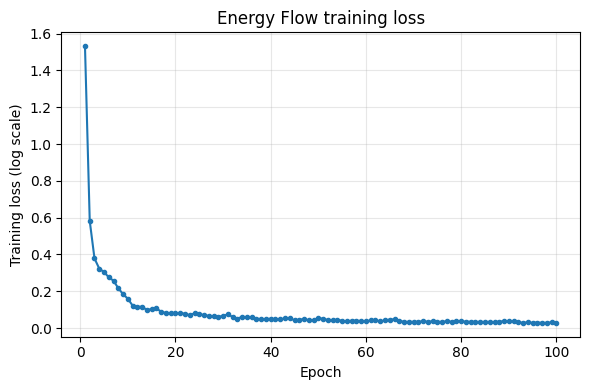

In [113]:
plt.figure(figsize=(6,4))
plt.plot(epochs_arr, loss_history, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training loss (log scale)")
plt.title("Energy Flow training loss")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



## Sampling: generare x dato c
- Genero un valore di x (cioè il mio pt normalizzato) dato il contesto c, integrando nel tempo il campo di velocità 

In [114]:
def sample_x_given_c(c, steps=50):
    """
    c: [B, Dc] (normalized)
    returns: x1_hat [B, Dx] (normalized)
    """
    vf.eval()

    # disattivo grad sui parametri (ma NON su x) -> durante il sampling non voglio aggiornare i pesi ma voglio ancora grad(x)
    was_req = []
    for p in vf.parameters():
        was_req.append(p.requires_grad)
        p.requires_grad_(False)

    B = c.shape[0]
    x = torch.randn((B, Dx), device=c.device)

    # Loop di integrazione ODE: Eulero 
    with torch.enable_grad():  
        for k in range(steps):
            t = torch.full((B,), k / steps, device=c.device)

            
            v = vf(x, t, c)      
            x = x + (1.0 / steps) * v

            
            x = x.detach()

    # ripristino requires_grad dei parametri
    for p, req in zip(vf.parameters(), was_req):
        p.requires_grad_(req)

    return x



In [115]:
x1_batch, c_batch = next(iter(dl))
c_batch = c_batch.to(device)[:1024]

x_hat_n = sample_x_given_c(c_batch, steps=80).cpu().numpy()
x_hat = scaler_X.inverse_transform(x_hat_n) # passaggio inverso della normalizzazione -> ora x_hat è in unità fisiche 

# check :
print(x_hat.shape)


(1024, 1)


In [116]:
# 1) prendo un batch dal dataloader
x_true_n, c_batch = next(iter(dl))   # normalized
x_true_n = x_true_n.to(device)
c_batch  = c_batch.to(device)

# (opzionale) riduco per velocità
B = 4096
x_true_n = x_true_n[:B]
c_batch  = c_batch[:B]

# 2) genero x_hat (normalized) con il sampler
x_hat_n = sample_x_given_c(c_batch, steps=80)   # tensor [B,1] normalized

# 3) porto su CPU e denormalizzo (torno in GeV)
x_true = scaler_X.inverse_transform(x_true_n.detach().cpu().numpy()) # [B, 1]
x_hat  = scaler_X.inverse_transform(x_hat_n.detach().cpu().numpy())  # [B, 1]


# 4) residui su pT
res = x_hat - x_true

rmse = float(np.sqrt(np.mean(res**2)))
bias = float(np.mean(res))

print("RMSE (pT_gen in GeV):", rmse)
print("BIAS (pT_gen in GeV):", bias)



RMSE (pT_gen in GeV): 0.9687584638595581
BIAS (pT_gen in GeV): -0.1309511661529541


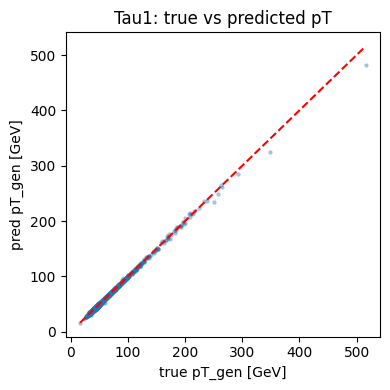

In [117]:
# usa i tensori che hai già calcolato
x_true1 = x_true[:,0]
x_hat1  = x_hat[:,0]

plt.figure(figsize=(4,4))
plt.scatter(x_true1, x_hat1, s=5, alpha=0.3)
lims = [min(x_true1.min(), x_hat1.min()), max(x_true1.max(), x_hat1.max())]
plt.plot(lims, lims, 'r--')  # y = x
plt.xlabel("true pT_gen [GeV]")
plt.ylabel("pred pT_gen [GeV]")
plt.title("Tau1: true vs predicted pT")
plt.tight_layout()
plt.show()


In [118]:
# x_true e x_hat sono già pT in GeV, shape (B,1)
pt_true = x_true[:, 0]
pt_hat  = x_hat[:, 0]

r = pt_hat / pt_true

print("Tau1 pT response: mean =", r.mean(), " std =", r.std())

p16, p50, p84 = np.percentile(r, [16, 50, 84])
print("Tau1 response percentili 16/50/84:", p16, p50, p84)



Tau1 pT response: mean = 0.9978585  std = 0.011954495
Tau1 response percentili 16/50/84: 0.9886644601821899 0.997196227312088 1.0069355249404908


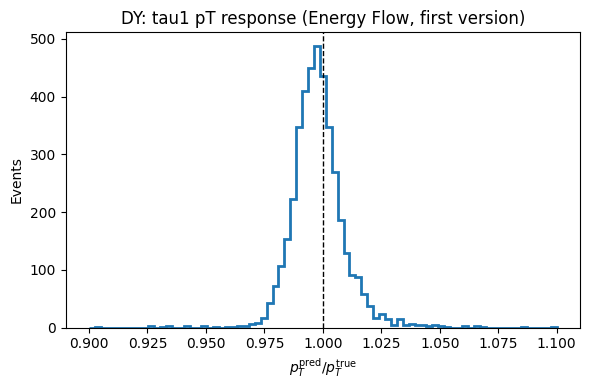

In [119]:
plt.figure(figsize=(6,4))

bins = np.linspace(0.9, 1.1, 80)

plt.hist(r, bins=bins, histtype="step", linewidth=2)

plt.axvline(1.0, color="k", linestyle="--", linewidth=1)

plt.xlabel(r"$p_T^{\mathrm{pred}} / p_T^{\mathrm{true}}$")
plt.ylabel("Events")
plt.title("DY: tau1 pT response (Energy Flow, first version)")
plt.tight_layout()
plt.show()


In [120]:
from torch.utils.data import Dataset, DataLoader

class IndexedDataset(Dataset):
    def __init__(self, X_t, C_t):
        self.X_t = X_t
        self.C_t = C_t
    def __len__(self):
        return len(self.X_t)
    def __getitem__(self, i):
        return self.X_t[i], self.C_t[i], i

dl_idx = DataLoader(IndexedDataset(X_t, C_t), batch_size=4096, shuffle=True, drop_last=True)


In [121]:
# batch con indici
x_true_n, c_batch, idx = next(iter(dl_idx))
x_true_n = x_true_n.to(device)
c_batch  = c_batch.to(device)
idx = idx.numpy()

# predizione (normalized -> GeV)
x_hat_n = sample_x_given_c(c_batch, steps=80).detach().cpu().numpy()
pt_pred = scaler_X.inverse_transform(x_hat_n).reshape(-1) # [B]

# gen true (normalized -> GeV)
pt_gen  = scaler_X.inverse_transform(
    x_true_n.detach().cpu().numpy()
).reshape(-1) # [B]
# reco pT dal dataframe: tau1_logpt è davvero log(pt)
sub = df_DY_tau1.iloc[idx]
pt_reco = np.exp(sub["tau1_logpt"].to_numpy(np.float32))  # [B]


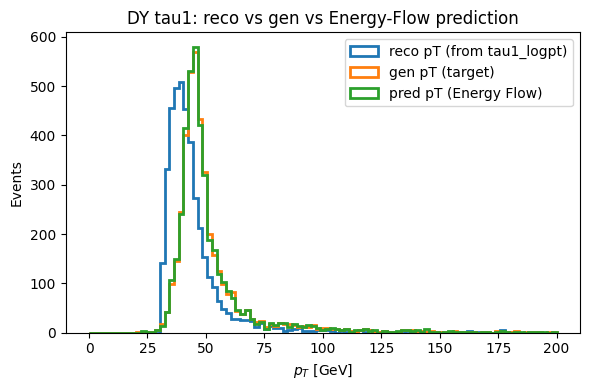

In [122]:
plt.figure(figsize=(6,4))
bins = np.linspace(0, 200, 100)

plt.hist(pt_reco, bins=bins, histtype="step", linewidth=2, label="reco pT (from tau1_logpt)")
plt.hist(pt_gen,  bins=bins, histtype="step", linewidth=2, label="gen pT (target)")
plt.hist(pt_pred, bins=bins, histtype="step", linewidth=2, label="pred pT (Energy Flow)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("DY tau1: reco vs gen vs Energy-Flow prediction")
plt.legend()
plt.tight_layout()
plt.show()


# Test su Higgs (modello addestrato su DY) $\rightarrow$ (?)

In [123]:
# stesso c_cols usato nel training DY
C_H = df_H_tau1[c_cols].to_numpy(np.float32)

# normalizzo 
C_Hn = scaler_C.transform(C_H).astype(np.float32)

c_H = torch.from_numpy(C_Hn).to(device)


In [63]:
# ============ NON RUNNARE -> CRASHA =============
# Genero pt pred su Higgs : 
with torch.no_grad():
    x_hat_H_n = sample_x_given_c(c_H, steps=80).cpu().numpy()

# denormalizzo con parametri DY
pt_pred_H = (x_hat_H_n * std_X + mu_X).reshape(-1)   # GeV

KeyboardInterrupt: 

In [124]:
def sample_in_batches(c_all, steps=80, batch_size=512):
    outs = []
    for i in range(0, c_all.shape[0], batch_size):
        c_b = c_all[i:i+batch_size]
        x_b = sample_x_given_c(c_b, steps=steps).detach().cpu().numpy()
        outs.append(x_b)
    return np.concatenate(outs, axis=0)

# c_H: Tensor [N, Dc] già su device e normalizzato
x_hat_H_n = sample_in_batches(c_H, steps=80, batch_size=512)

pt_pred_H = scaler_X.inverse_transform(x_hat_H_n).reshape(-1)

In [125]:
# gen (truth Higgs)
pt_gen_H = df_H_tau1["gen_tau1_logpt"].to_numpy(np.float32)   # è già pT in GeV (non è log !!!)

# reco (Higgs)
pt_reco_H = np.exp(df_H_tau1["tau1_logpt"].to_numpy(np.float32))

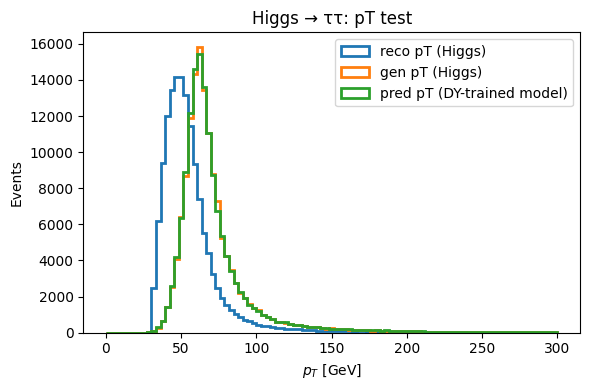

In [127]:
bins = np.linspace(0, 300, 100)

plt.figure(figsize=(6,4))
plt.hist(pt_reco_H, bins=bins, histtype="step", linewidth=2, label="reco pT (Higgs)")
plt.hist(pt_gen_H,  bins=bins, histtype="step", linewidth=2, label="gen pT (Higgs)")
plt.hist(pt_pred_H, bins=bins, histtype="step", linewidth=2, label="pred pT (DY-trained model)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Higgs → ττ: pT test")
plt.legend()
plt.tight_layout()
plt.show()

# Test
Applico il modello trainato su tau1-DY a tau2-DY

In [129]:
# ---- costruisco le colonne contesto per tau2 mantenendo l'ordine del training ----
c_cols_tau2 = [col.replace("tau1_", "tau2_") for col in c_cols]  # inv_mass_reco resta uguale

# check rapido: colonne mancanti 
missing = [col for col in c_cols_tau2 if col not in df_DY_tau2.columns]
print("Missing columns:", missing)

# ---- estraggo, normalizzo con lo scaler del training, porto su torch ----
C_DY2 = df_DY_tau2[c_cols_tau2].to_numpy(np.float32)
C_DY2_n = scaler_C.transform(C_DY2).astype(np.float32)

c_DY = torch.from_numpy(C_DY2_n).to(device)
print("c_DY shape:", c_DY.shape)


Missing columns: []
c_DY shape: torch.Size([60113, 31])


In [130]:
x_hat_DY_n = sample_in_batches(c_DY, steps=80, batch_size=512)
pt_pred_DY = scaler_X.inverse_transform(x_hat_DY_n).reshape(-1)

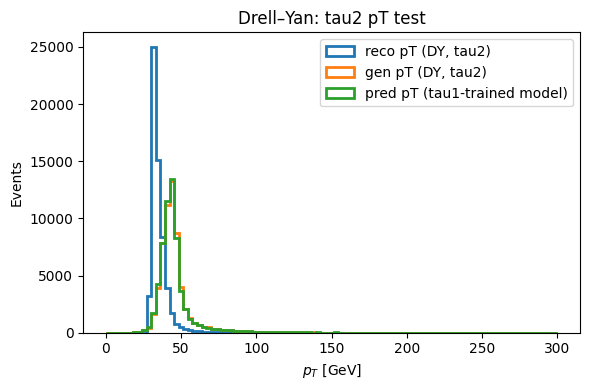

In [131]:
# gen (truth DY)  -- ATTENZIONE: non è log
pt_gen_DY = df_DY_tau2["gen_tau2_logpt"].to_numpy(np.float32)

# reco (DY)  -- qui è log 
pt_reco_DY = np.exp(df_DY_tau2["tau2_logpt"].to_numpy(np.float32))

bins = np.linspace(0, 300, 100)

plt.figure(figsize=(6,4))
plt.hist(pt_reco_DY, bins=bins, histtype="step", linewidth=2, label="reco pT (DY, tau2)")
plt.hist(pt_gen_DY,  bins=bins, histtype="step", linewidth=2, label="gen pT (DY, tau2)")
plt.hist(pt_pred_DY, bins=bins, histtype="step", linewidth=2, label="pred pT (tau1-trained model)")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Drell–Yan: tau2 pT test")
plt.legend()
plt.tight_layout()
plt.show()
